# Lab 13: Unsupervised Learning - K-Means & K-Medoids

## 1. K-Means Clustering with Cost Analysis

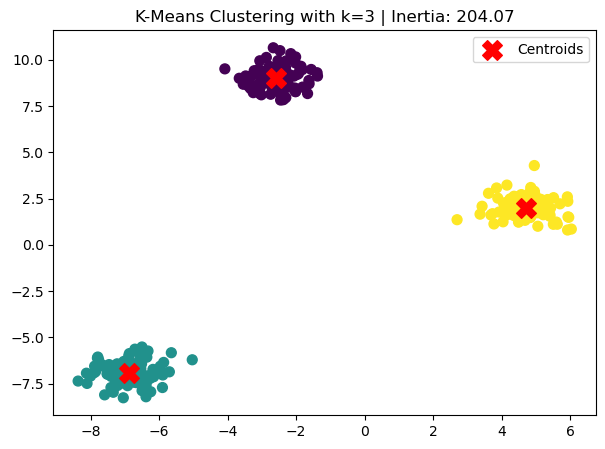

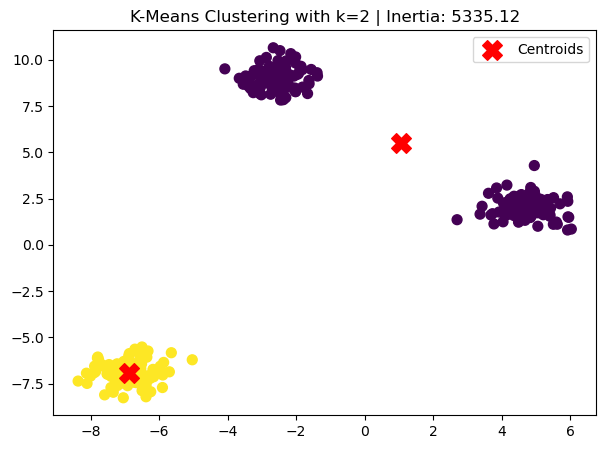

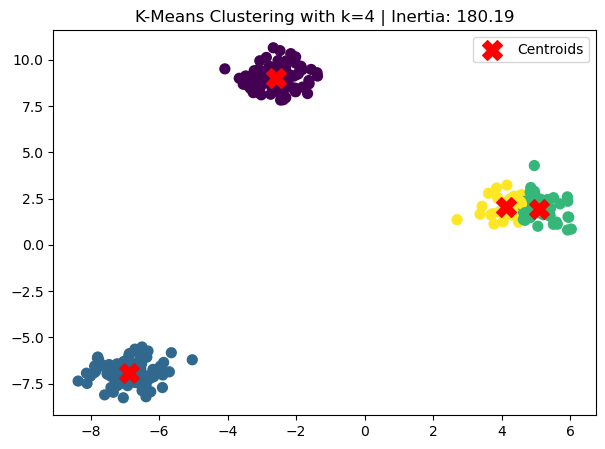

Inertia for k=2: 5335.12
Inertia for k=3: 204.07
Inertia for k=4: 180.19


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generating synthetic dataset
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)

def analyze_kmeans(k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)
    centroids = kmeans.cluster_centers_
    inertia = kmeans.inertia_
    
    plt.figure(figsize=(7, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
    plt.title(f'K-Means Clustering with k={k} | Inertia: {inertia:.2f}')
    plt.legend()
    plt.show()
    return inertia

inertia_3 = analyze_kmeans(3)
inertia_2 = analyze_kmeans(2)
inertia_4 = analyze_kmeans(4)

print(f'Inertia for k=2: {inertia_2:.2f}')
print(f'Inertia for k=3: {inertia_3:.2f}')
print(f'Inertia for k=4: {inertia_4:.2f}')

1) **Why does inertia decrease as k increases?**
  When we add more clusters, each data point is naturally closer to its assigned centroid. Since inertia is the sum of squared distances to the nearest center, more centers mean smaller distances on average.
2) **Does lower inertia always mean better clustering?**
  Not always. If k is too high (overfitting), we might just be partitioning noise. A lower inertia only means the clusters are tighter, but it doesn't guarantee the groups are meaningful.

## 2. Elbow Method for Optimal k

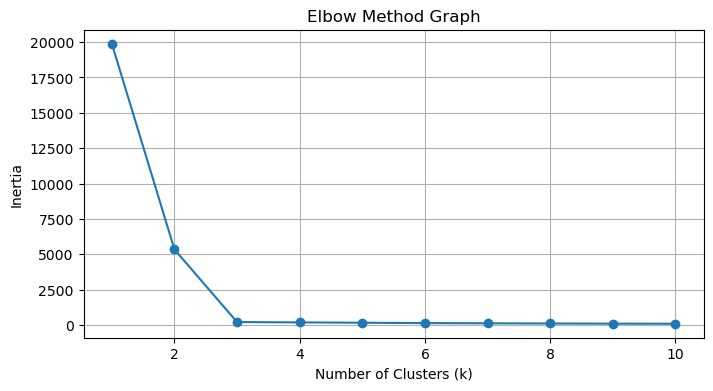

In [2]:
inertias = []
k_vals = range(1, 11)

for k in k_vals:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_vals, inertias, marker='o')
plt.title('Elbow Method Graph')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

1) **What is the "elbow point"?**
  It's the point where the rate of inertia decrease significantly drops. In our case, the elbow is at **k=3**.
2) **Why is it important?**
  It provides a mathematical heuristic to choose a balanced value for k that captures data structure without over-complicating the model.
3) **What happens if k is too large or too small?**
  If k is too small, we merge distinct groups incorrectly. If k is too large, we split natural groups into artificial segments.

## 3. K-Means vs K-Medoids Comparison

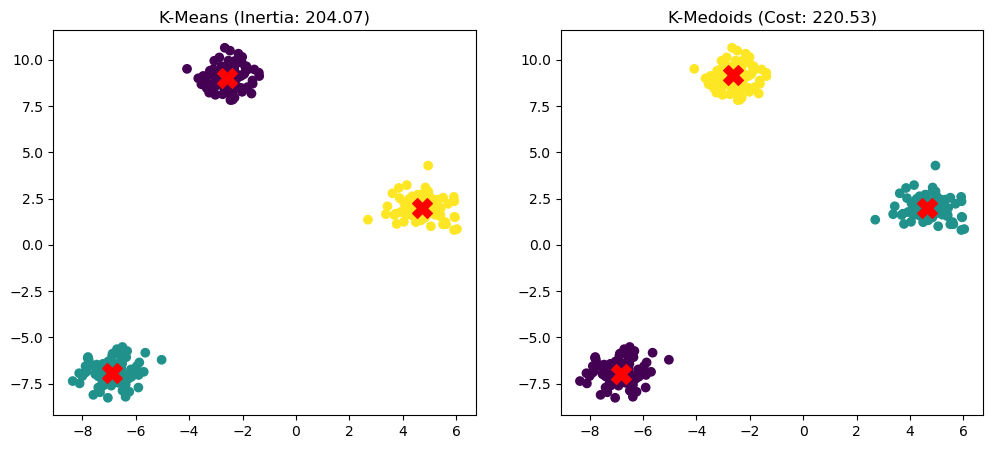

In [3]:
# Note: you may need to run !pip install scikit-learn-extra
from sklearn_extra.cluster import KMedoids

k_means = KMeans(n_clusters=3, random_state=42, n_init='auto').fit(X)
k_medoids = KMedoids(n_clusters=3, method='pam', random_state=42).fit(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X[:, 0], X[:, 1], c=k_means.labels_)
ax1.scatter(k_means.cluster_centers_[:, 0], k_means.cluster_centers_[:, 1], c='red', marker='X', s=200)
ax1.set_title(f'K-Means (Inertia: {k_means.inertia_:.2f})')

ax2.scatter(X[:, 0], X[:, 1], c=k_medoids.labels_)
ax2.scatter(k_medoids.cluster_centers_[:, 0], k_medoids.cluster_centers_[:, 1], c='red', marker='X', s=200)
ax2.set_title(f'K-Medoids (Cost: {k_medoids.inertia_:.2f})')

plt.show()

1) **Why does K-Medoids use actual data points?**
  Because a medoid is defined as the object within a cluster whose average dissimilarity to all other objects in the cluster is minimal.
2) **Robustness to outliers?**
  K-Medoids is more robust. K-Means (using means) is easily skewed by extreme values, whereas K-Medoids just picks a different central point.
3) **Computational Expense?**
  K-Medoids is more expensive because the PAM algorithm requires calculating distances for every potential swap of medoids.

## 4. Effect of Outliers on Clustering
Let's see what happens when we throw in some very distant points.

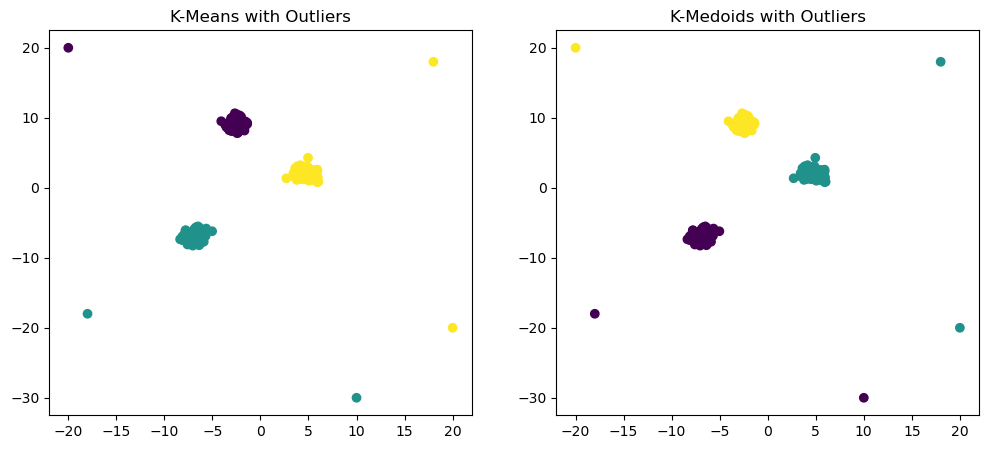

In [4]:
outliers = np.array([[18, 18], [-18, -18], [20, -20], [-20, 20], [10, -30]])
X_with_outliers = np.vstack([X, outliers])

km_out = KMeans(n_clusters=3, random_state=42, n_init='auto').fit(X_with_outliers)
kmed_out = KMedoids(n_clusters=3, method='pam', random_state=42).fit(X_with_outliers)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X_with_outliers[:, 0], X_with_outliers[:, 1], c=km_out.labels_)
ax1.set_title('K-Means with Outliers')
ax2.scatter(X_with_outliers[:, 0], X_with_outliers[:, 1], c=kmed_out.labels_)
ax2.set_title('K-Medoids with Outliers')
plt.show()

1) **Which is more affected?**
  K-Means. The centroids will be visibly shifted toward the outliers because the mean is sensitive to extreme values.
2) **Mathematical reason?**
  K-Means minimizes the sum of *squared* Euclidean distances. Squaring an outlier's distance makes its influence disproportionately large.

## 5. Distance Metric Exploration
Testing Euclidean vs Manhattan distance in K-Medoids.

In [5]:
model_euc = KMedoids(n_clusters=3, metric='euclidean', random_state=42).fit(X)
model_man = KMedoids(n_clusters=3, metric='manhattan', random_state=42).fit(X)

print(f'Total Cost (Euclidean): {model_euc.inertia_:.2f}')
print(f'Total Cost (Manhattan): {model_man.inertia_:.2f}')

Total Cost (Euclidean): 220.53
Total Cost (Manhattan): 279.64


1) **Effect?** Different distance metrics can lead to different cluster shapes and center placements.
2) **Manhattan vs Euclidean?** Manhattan (L1) is often preferred when the data has many outliers or is high-dimensional, as it reduces the impact of extreme deviations compared to the squared nature of Euclidean distance.